In [31]:
# import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import (classification_report, precision_score, recall_score, f1_score,
                               ConfusionMatrixDisplay)
from sklearn.utils    import check_random_state

# warnings.filterwarnings("ignore")
import importlib.util
import sys

file_path = '/home/miguel/GoogleDriveOffline/2026/Tesis-1/Codes/Core/Predicciones/FollowingStrategy/GetLabeledEvents.py'  # Update this path to your actual file location
module_name = 'GetLabeledEvents' # The name you want to use internally

# Load the module specification from the file path
spec = importlib.util.spec_from_file_location(module_name, file_path)

if spec and spec.loader:
    # Create a new module based on the spec
    module = importlib.util.module_from_spec(spec)
    
    # Optional: Add it to sys.modules so it behaves like a normal cached import
    sys.modules[module_name] = module
    
    # Execute the module to populate its namespace
    spec.loader.exec_module(module)
    
else:
    print(f"Could not load module from {file_path}")

lv = module

In [32]:
def load_tickers_from_file(file_path: str) -> list:
    """
    Loads tickers from a text file, one ticker per line.
    """
    with open(file_path, 'r') as f:
        tickers = [line.strip() for line in f if line.strip()]
    return tickers

ticker_file = r"/home/miguel/GoogleDriveOffline/Data/tickers/sp500_tickers_Energy.csv"

tickers = load_tickers_from_file(ticker_file)

Let $I$ be the set of all labeled events. Each event $i \in I$ is defined by a start time mapping to an entry index $t_{i, \text{start}}$ and an end time (t_hit) mapping to an exit index $t_{i, \text{end}}$ on a discrete time grid $T$ of length $N$ (the close_index).1. Concurrency ($c_t$)First, the function calculates the number of concurrently active events at every time step $t \in T$. The concurrency $c_t$ is the sum of indicator functions for all valid events:$$c_t = \sum_{i \in I} \mathbb{I}(t_{i, \text{start}} \le t \le t_{i, \text{end}})$$Where $\mathbb{I}(\cdot)$ is the indicator function, evaluating to $1$ if the condition is true and $0$ otherwise.2. Sample Weight ($w_i$)The uniqueness of an event at time $t$ is defined as $\frac{1}{c_t}$. The sample weight $w_i$ for a single event $i$ is the arithmetic mean of the uniqueness across all time steps during its lifespan $L_i$, where $L_i = t_{i, \text{end}} - t_{i, \text{start}} + 1$:$$w_i = \frac{1}{L_i} \sum_{t = t_{i, \text{start}}}^{t_{i, \text{end}}} \frac{1}{c_t}$$If an event lacks a valid end time (t_hit is NaN) or cannot be mapped to the index (ep == -1), the function explicitly assigns a default weight:$$w_i = 0$$

In [46]:
import pandas as pd
import numpy as np

# ── Hyper-parameters (mirror v2) ──────────────────────────────────────────
FAST_SPAN = 15
SLOW_SPAN = 50
BURN_IN   = SLOW_SPAN * 3
NUM_BARS  = 63          # vertical barrier
PT_SL     = [1.0, 1.0]  # symmetric barriers
MIN_RET   = 0.001
VOL_SPAN  = 20

def compute_sample_weights(labeled: pd.DataFrame,
                           close_index: pd.Index) -> pd.Series:
    """
    Compute average-uniqueness sample weights for each labeled event.
    Unresolved events (NaN t_hit) are assigned a weight of 0.0 (excluded).
    """
    # 1. Isolate only fully resolved events
    ev = labeled[['t_hit']].dropna(subset=['t_hit']).copy()
    ev['t_hit'] = pd.to_datetime(ev['t_hit'])

    n_bars = len(close_index)
    
    # 2. Map timestamps to integer indices
    entry_pos = close_index.get_indexer(ev.index, method='bfill')
    exit_pos  = close_index.get_indexer(ev['t_hit'], method='bfill')

    # Filter out events that could not be mapped to the index
    valid_mask = entry_pos != -1
    valid_entries = entry_pos[valid_mask]
    valid_exits = exit_pos[valid_mask]
    
    # Clamp exit positions to the bounds of the close_index
    valid_exits = np.where((valid_exits == -1) | (valid_exits >= n_bars), n_bars - 1, valid_exits)

    # 3. Optimized Concurrency Calculation O(M + N) via difference array
    diff_array = np.zeros(n_bars + 1, dtype=np.float32)
    for ep, xp in zip(valid_entries, valid_exits):
        diff_array[ep] += 1.0
        diff_array[xp + 1] -= 1.0  
        
    concurrent = np.cumsum(diff_array)[:-1] 
    
    # Pre-calculate uniqueness to avoid repeated division
    concurrent = np.where(concurrent > 0, concurrent, 1.0)
    uniqueness = 1.0 / concurrent

    # 4. Compute Weights
    partial_weights = {}
    valid_indices = ev.index[valid_mask]
    for ts, ep, xp in zip(valid_indices, valid_entries, valid_exits):
        partial_weights[ts] = float(np.mean(uniqueness[ep : xp + 1]))

    # 5. FIX-1 Resolved: Map back to the full index, but assign 0.0 to unresolved events
    weights = pd.Series(0.0, index=labeled.index, name='weight')
    for ts, w in partial_weights.items():
        weights[ts] = w
        
    return weights


X_parts            = []   # list of DataFrames with MultiIndex
y_parts            = []   # list of Series   with MultiIndex
weight_parts       = []   # list of Series   with MultiIndex
all_labeled_events = []

def orchestrate_processing(ticker: str):
    DATA_PATH = (f"/home/miguel/GoogleDriveOffline/Data/DataTickersDollar/"
                 f"{ticker}_2015_to_2026_dollar_bars.csv")
    df = pd.read_csv(DATA_PATH)

    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp').sort_index()
    elif df.index.name != 'timestamp':
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()

    close_col = 'close' if 'close' in df.columns else 'Close'
    if close_col not in df.columns:
        raise KeyError(f"No close column found for {ticker}. "
                       f"Available: {list(df.columns)}")
    close = df[close_col]

    cross_events = lv.get_crossover_events(
        close, fast_span=FAST_SPAN, slow_span=SLOW_SPAN, burn_in=BURN_IN)

    labeled = lv.get_labeled_events(
        close, cross_events,
        pt_sl=PT_SL, vol_span=VOL_SPAN, min_ret=MIN_RET, num_bars=NUM_BARS)

    print(f"{ticker}: {len(df)} bars | {len(cross_events)} crossings | "
          f"{len(labeled)} labeled events")
    
    X_ticker = lv.build_features(
        close, cross_events, fast_span=FAST_SPAN, slow_span=SLOW_SPAN)

    # Align features to labeled event times
    X_ticker = X_ticker.reindex(labeled.index)
    mask     = X_ticker.notna().all(axis=1)
    X_ticker = X_ticker[mask]
    y_ticker = labeled.loc[mask, 'meta_label']

    # FIX-1: weights now always have the same index as X_ticker / y_ticker
    weights_ticker = compute_sample_weights(labeled.loc[mask], close.index)

    print(f"  Feature matrix: {X_ticker.shape} | "
          f"NaN rows dropped: {(~mask).sum()}")

    # ── FIX-2: build a MultiIndex (ticker, event_time) ───────────────────────
    mi = pd.MultiIndex.from_arrays(
        [np.full(len(X_ticker), ticker), X_ticker.index],
        names=['ticker', 'event_time'])
    X_ticker.index      = mi
    y_ticker.index      = mi
    weights_ticker.index = mi

    return X_ticker, y_ticker, weights_ticker, labeled.loc[mask]

for ticker in tickers:
    X_ticker, y_ticker, weights_ticker, labeled = orchestrate_processing(ticker)
    X_parts.append(X_ticker)
    y_parts.append(y_ticker)
    weight_parts.append(weights_ticker)

    idx_name = labeled.index.name or 'index'
    labeled_copy = labeled.copy().reset_index()
    labeled_copy = labeled_copy.rename(columns={idx_name: 'event_time'})
    labeled_copy.insert(0, 'ticker', ticker)
    all_labeled_events.append(labeled_copy)

# Concatenate all X, y, weights, and labeled events into single DataFrames
X_all      = pd.concat(X_parts)       # index = (ticker, event_time)
y_all      = pd.concat(y_parts)
weights_all = pd.concat(weight_parts)
labeled_all = pd.concat(all_labeled_events, ignore_index=True)

# Alignment guard — will raise immediately if something is off
assert X_all.index.equals(y_all.index),       "X / y index mismatch!"
assert X_all.index.equals(weights_all.index), "X / weights index mismatch!"

event_times = X_all.index.get_level_values('event_time')  # DatetimeIndex
feature_cols = list(X_all.columns)                         # all cols are features

print(f"\n{'='*70}")
print(f"Combined feature matrix X : {X_all.shape}")
print(f"Combined labels y         : {y_all.shape}")
print(f"Combined weights          : {weights_all.shape}")
print(f"Tickers                   : {labeled_all['ticker'].nunique()}")
print(f"{'='*70}\n")
print("Label distribution:")
print(y_all.value_counts().sort_index())
print(f"\nSample weights — mean: {weights_all.mean():.4f} "
      f"| min: {weights_all.min():.4f} "
      f"| max: {weights_all.max():.4f}")

APA: 1526 bars | 29 crossings | 29 labeled events
  Feature matrix: (29, 9) | NaN rows dropped: 0
BKR: 1456 bars | 34 crossings | 34 labeled events
  Feature matrix: (34, 9) | NaN rows dropped: 0
CVX: 1880 bars | 49 crossings | 49 labeled events
  Feature matrix: (49, 9) | NaN rows dropped: 0
COP: 1617 bars | 30 crossings | 30 labeled events
  Feature matrix: (30, 9) | NaN rows dropped: 0
DVN: 1017 bars | 11 crossings | 11 labeled events
  Feature matrix: (11, 9) | NaN rows dropped: 0
FANG: 584 bars | 14 crossings | 14 labeled events
  Feature matrix: (14, 9) | NaN rows dropped: 0
EOG: 1390 bars | 23 crossings | 23 labeled events
  Feature matrix: (23, 9) | NaN rows dropped: 0
EQT: 853 bars | 17 crossings | 17 labeled events
  Feature matrix: (17, 9) | NaN rows dropped: 0
EXE: 1355 bars | 29 crossings | 29 labeled events
  Feature matrix: (29, 9) | NaN rows dropped: 0
XOM: 1929 bars | 36 crossings | 36 labeled events
  Feature matrix: (36, 9) | NaN rows dropped: 0
HAL: 1702 bars | 31 c

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

TRAIN_FRAC    = 0.70
EMBARGO_BARS  = 0 #NUM_BARS   # same width as the vertical barrier
RANDOM_STATE  = 42

# Sort all rows by event_time (global chronological order)
sort_order   = np.argsort(event_times.to_numpy(), kind='stable')  # stable keeps ticker ties
sorted_times = event_times[sort_order]
n_events     = len(X_all)
n_train      = int(n_events * TRAIN_FRAC)

train_mask = np.zeros(n_events, dtype=bool)
train_mask[:n_train] = True          # first 70 % by time

test_mask = ~train_mask
if EMBARGO_BARS > 0:
    # The last n_train rows are train; skip the next EMBARGO_BARS rows
    embargo_end = n_train + EMBARGO_BARS          # index into sorted order
    test_mask[:embargo_end] = False   


# Map sorted positions back to original (unsorted) positional indices in X_all
train_indices = sort_order[train_mask]
test_indices  = sort_order[test_mask]

# Diagnostic: per-ticker event counts in train vs test
print("Per-ticker train / test split:")
ticker_level = X_all.index.get_level_values('ticker')
for t in sorted(set(ticker_level)):
    n_tr = (ticker_level[train_indices] == t).sum()
    n_te = (ticker_level[test_indices]  == t).sum()
    print(f"  {t:6s}  train={n_tr:4d}  test={n_te:4d}")
print()

# Extract columns (excluding event_time which we added for splitting)
feature_cols = [c for c in X_all.columns if c != 'event_time']

X_vals = X_all.to_numpy()
y_vals = y_all.to_numpy()
w_vals = weights_all.to_numpy()

X_train_raw = X_vals[train_indices]
X_test_raw  = X_vals[test_indices]
y_train     = y_vals[train_indices]
y_test      = y_vals[test_indices]
w_train     = w_vals[train_indices]
w_test      = w_vals[test_indices]

train_times_arr = event_times[train_indices]
test_times_arr  = event_times[test_indices]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit on train → no leakage
X_test  = scaler.transform(X_test_raw)        # apply same scale to test

print(f"Train events : {len(X_train):5d}  "
      f"({pd.Timestamp(train_times_arr.min()).date()} → "
      f"{pd.Timestamp(train_times_arr.max()).date()})")
print(f"Test events  : {len(X_test):5d}  "
      f"({pd.Timestamp(test_times_arr.min()).date()} → "
      f"{pd.Timestamp(test_times_arr.max()).date()})")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")
print(f"Embargo rows dropped: {EMBARGO_BARS} (= NUM_BARS = {NUM_BARS})")

# ── Random Forest (unchanged) ─────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators            = 500,
    max_depth               = 3,
    min_weight_fraction_leaf= 0.3,
    max_features            = 'sqrt',
    criterion = 'entropy',
    class_weight            = 'balanced_subsample',
    n_jobs                  = -1,
    random_state            = RANDOM_STATE,
)
rf.fit(X_train, y_train, sample_weight=w_train)
print("\nRandom Forest trained.")

Per-ticker train / test split:
  APA     train=  24  test=   5
  BKR     train=  22  test=  12
  COP     train=  17  test=  13
  CVX     train=  33  test=  16
  DVN     train=  10  test=   1
  EOG     train=  18  test=   5
  EQT     train=   8  test=   9
  EXE     train=  13  test=  16
  FANG    train=  12  test=   2
  HAL     train=  27  test=   4
  KMI     train=  26  test=  18
  MPC     train=  21  test=   3
  OKE     train=   9  test=   3
  OXY     train=  23  test=   0
  PSX     train=  25  test=   3
  SLB     train=  31  test=  22
  TPL     train=  15  test=   2
  TRGP    train=   7  test=   0
  VLO     train=  27  test=   9
  WMB     train=   4  test=  12
  XOM     train=  22  test=  14

Train events :   394  (2017-04-18 → 2023-07-07)
Test events  :   169  (2023-07-13 → 2026-04-23)
Train positive rate: 0.515
Test  positive rate: 0.473
Embargo rows dropped: 0 (= NUM_BARS = 63)

Random Forest trained.


In [48]:
# Calculate the number of parameters in the Random Forest

n_trees = rf.n_estimators
n_features = rf.n_features_in_
max_depth = rf.max_depth

# Estimate nodes per tree (approximate for a balanced tree)
# Maximum nodes in a tree of depth d: 2^(d+1) - 1
max_nodes_per_tree = 2 ** (max_depth + 1) - 1

# Total parameters: each node has a split threshold + feature index
# Rough estimate: nodes * (1 feature index + 1 threshold) per node
params_per_tree = max_nodes_per_tree * 2

total_params_estimate = n_trees * params_per_tree

print(f"Random Forest Model Complexity")
print(f"=" * 50)
print(f"Number of trees: {n_trees}")
print(f"Number of features: {n_features}")
print(f"Max depth per tree: {max_depth}")
print(f"Max nodes per tree: {max_nodes_per_tree}")
print(f"Parameters per tree (estimate): {params_per_tree}")
print(f"Total parameters (estimate): {total_params_estimate:,}")
print(f"\nActual leaf count (trained trees):")

# Count actual nodes/leaves in trained trees
total_actual_leaves = sum(tree.tree_.node_count for tree in rf.estimators_)
print(f"Total nodes across all trees: {total_actual_leaves:,}")
print(f"Average nodes per tree: {total_actual_leaves / n_trees:.0f}")

Random Forest Model Complexity
Number of trees: 500
Number of features: 9
Max depth per tree: 3
Max nodes per tree: 15
Parameters per tree (estimate): 30
Total parameters (estimate): 15,000

Actual leaf count (trained trees):
Total nodes across all trees: 2,118
Average nodes per tree: 4


The fundamental difference lies in how each event contributes to the confusion matrix (True Positives, False Positives, True Negatives, False Negatives).Unweighted Metrics (Standard)Every observation $i$ has an implicit weight of $1$. The metrics are simple counts.Unweighted Precision:$$P = \frac{\sum_{i} \mathbb{I}(\hat{y}_i=1 \land y_i=1)}{\sum_{i} \mathbb{I}(\hat{y}_i=1)}$$Weighted MetricsEach observation $i$ contributes its specific sample weight $w_i$ (e.g., uniqueness or return-based weighting).Weighted Precision:$$P_{w} = \frac{\sum_{i} w_i \cdot \mathbb{I}(\hat{y}_i=1 \land y_i=1)}{\sum_{i} w_i \cdot \mathbb{I}(\hat{y}_i=1)}$$

Meta-label classifier — weighted precision / recall / F1
               Precision  Recall     F1
Model                                  
RF train          0.5943  0.6393 0.6160
RF test           0.5045  0.6018 0.5489
Primary train     0.5220  1.0000 0.6860
Primary test      0.4842  1.0000 0.6524

Comparison on test set (RF - primary)
  Precision delta: +0.0204
  F1 delta       : -0.1035

── Test set report (unweighted) ──
              precision    recall  f1-score   support

    Skip (0)       0.55      0.39      0.46        89
   Trade (1)       0.49      0.64      0.55        80

    accuracy                           0.51       169
   macro avg       0.52      0.52      0.50       169
weighted avg       0.52      0.51      0.50       169



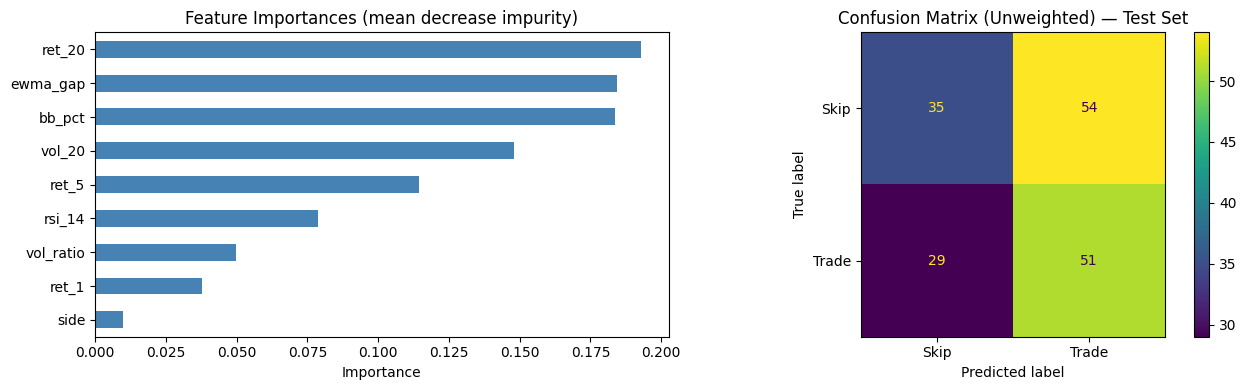

In [49]:
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

# Primary model baseline: always take the trade (predict class 1 for every event)
y_pred_train_primary = np.ones_like(y_train, dtype=int)
y_pred_test_primary  = np.ones_like(y_test, dtype=int)

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

def weighted_metrics(y_true, y_pred, weights):
    return {
        'Precision': precision_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        'Recall': recall_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        'F1': f1_score(y_true, y_pred, sample_weight=weights, zero_division=0),
    }

rf_train_metrics = weighted_metrics(y_train, y_pred_train, w_train)
rf_test_metrics = weighted_metrics(y_test, y_pred_test, w_test)
primary_train_metrics = weighted_metrics(y_train, y_pred_train_primary, w_train)
primary_test_metrics = weighted_metrics(y_test, y_pred_test_primary, w_test)

metrics_table = pd.DataFrame([
    {'Model': 'RF train', **rf_train_metrics},
    {'Model': 'RF test', **rf_test_metrics},
    {'Model': 'Primary train', **primary_train_metrics},
    {'Model': 'Primary test', **primary_test_metrics},
]).set_index('Model')

print("=" * 78)
print("Meta-label classifier — weighted precision / recall / F1")
print("=" * 78)
print(metrics_table.to_string(float_format=lambda x: f'{x:.4f}'))
print()
print("Comparison on test set (RF - primary)")
print(f"  Precision delta: {rf_test_metrics['Precision'] - primary_test_metrics['Precision']:+.4f}")
print(f"  F1 delta       : {rf_test_metrics['F1'] - primary_test_metrics['F1']:+.4f}")
print()
print("── Test set report (unweighted) ──")
print(classification_report(y_test, y_pred_test,
                             target_names=['Skip (0)', 'Trade (1)'],
                             zero_division=0))

# ── Feature importance ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importances (mean decrease impurity)')
axes[0].set_xlabel('Importance')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['Skip', 'Trade'],
    ax=axes[1], colorbar=True
)
axes[1].set_title('Confusion Matrix (Unweighted) — Test Set')

plt.tight_layout()
plt.show()
